<a href="https://colab.research.google.com/github/sarath287/COVID-19-Data-Analysis-Visualization-India/blob/main/COVID_19_Data_Analysis_%26_Visualization2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
filepath="covid_19_india.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sudalairajkumar/covid19-in-india",filepath)


/tmp/ipykernel_1151/2467957263.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 982k/982k [00:00<00:00, 5.34MB/s]


In [2]:
print("First 5 records:", df.head())

First 5 records:    Sno        Date     Time State/UnionTerritory ConfirmedIndianNational  \
0    1  2020-01-30  6:00 PM               Kerala                       1   
1    2  2020-01-31  6:00 PM               Kerala                       1   
2    3  2020-02-01  6:00 PM               Kerala                       2   
3    4  2020-02-02  6:00 PM               Kerala                       3   
4    5  2020-02-03  6:00 PM               Kerala                       3   

  ConfirmedForeignNational  Cured  Deaths  Confirmed  
0                        0      0       0          1  
1                        0      0       0          1  
2                        0      0       0          2  
3                        0      0       0          3  
4                        0      0       0          3  


In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# The file was already loaded into 'df' via kagglehub
covid_data = df
print(covid_data.head())

   Sno        Date     Time State/UnionTerritory ConfirmedIndianNational  \
0    1  2020-01-30  6:00 PM               Kerala                       1   
1    2  2020-01-31  6:00 PM               Kerala                       1   
2    3  2020-02-01  6:00 PM               Kerala                       2   
3    4  2020-02-02  6:00 PM               Kerala                       3   
4    5  2020-02-03  6:00 PM               Kerala                       3   

  ConfirmedForeignNational  Cured  Deaths  Confirmed  
0                        0      0       0          1  
1                        0      0       0          1  
2                        0      0       0          2  
3                        0      0       0          3  
4                        0      0       0          3  


In [9]:
print(covid_data.head())
print(covid_data.columns)
print(covid_data.info())

   Sno        Date     Time State/UnionTerritory ConfirmedIndianNational  \
0    1  2020-01-30  6:00 PM               Kerala                       1   
1    2  2020-01-31  6:00 PM               Kerala                       1   
2    3  2020-02-01  6:00 PM               Kerala                       2   
3    4  2020-02-02  6:00 PM               Kerala                       3   
4    5  2020-02-03  6:00 PM               Kerala                       3   

  ConfirmedForeignNational  Cured  Deaths  Confirmed  
0                        0      0       0          1  
1                        0      0       0          1  
2                        0      0       0          2  
3                        0      0       0          3  
4                        0      0       0          3  
Index(['Sno', 'Date', 'Time', 'State/UnionTerritory',
       'ConfirmedIndianNational', 'ConfirmedForeignNational', 'Cured',
       'Deaths', 'Confirmed'],
      dtype='object')
<class 'pandas.core.frame.DataFrame

In [10]:
covid_data.isnull().sum()

,0
Sno,0
Date,0
Time,0
State/UnionTerritory,0
ConfirmedIndianNational,0
ConfirmedForeignNational,0
Cured,0
Deaths,0
Confirmed,0


In [11]:
covid_data['Date'] = pd.to_datetime(covid_data['Date'])

In [12]:
india_daily = covid_data.groupby('Date')[['Confirmed', 'Cured', 'Deaths']].sum()
print(india_daily.head())

            Confirmed  Cured  Deaths
Date                                
2020-01-30          1      0       0
2020-01-31          1      0       0
2020-02-01          2      0       0
2020-02-02          3      0       0
2020-02-03          3      0       0


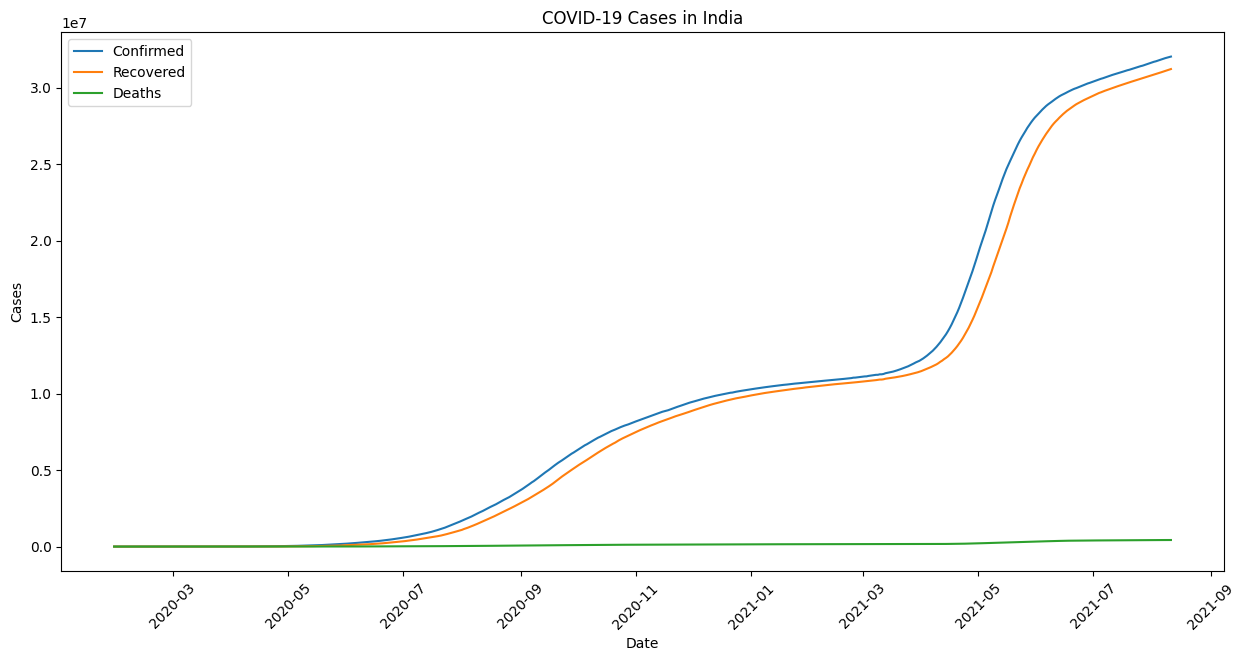

In [13]:
plt.figure(figsize=(15,7))

plt.plot(india_daily.index,
         india_daily['Confirmed'],
         label='Confirmed')

plt.plot(india_daily.index,
         india_daily['Cured'],
         label='Recovered')

plt.plot(india_daily.index,
         india_daily['Deaths'],
         label='Deaths')

plt.xlabel("Date")
plt.ylabel("Cases")
plt.title("COVID-19 Cases in India")
plt.legend()

plt.xticks(rotation=45)

plt.show()

In [14]:
karnataka_data = covid_data[
    covid_data['State/UnionTerritory'] == 'Karnataka'
]

In [15]:
print(karnataka_data.head())

     Sno       Date     Time State/UnionTerritory ConfirmedIndianNational  \
74    75 2020-03-09  6:00 PM            Karnataka                       1   
89    90 2020-03-10  6:00 PM            Karnataka                       4   
108  109 2020-03-11  6:00 PM            Karnataka                       4   
119  120 2020-03-12  6:00 PM            Karnataka                       4   
132  133 2020-03-13  6:00 PM            Karnataka                       6   

    ConfirmedForeignNational  Cured  Deaths  Confirmed  
74                         0      0       0          1  
89                         0      0       0          4  
108                        0      0       0          4  
119                        0      0       0          4  
132                        0      0       1          6  


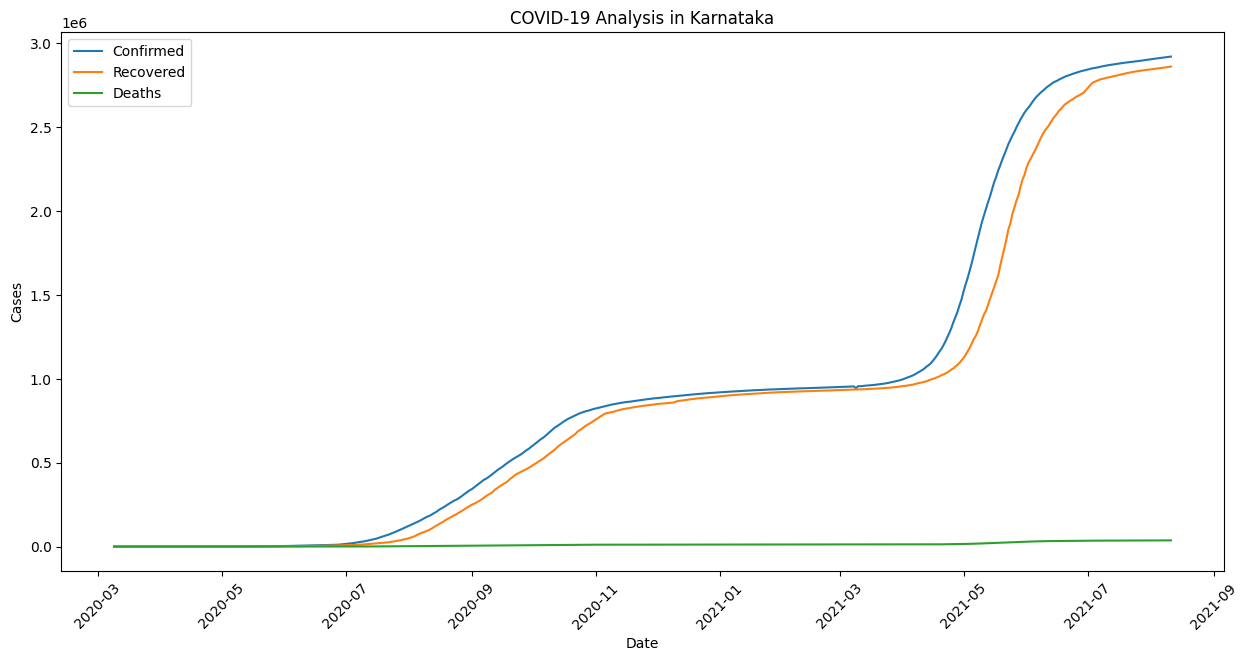

In [16]:
plt.figure(figsize=(15,7))

plt.plot(
    karnataka_data['Date'],
    karnataka_data['Confirmed'],
    label='Confirmed'
)

plt.plot(
    karnataka_data['Date'],
    karnataka_data['Cured'],
    label='Recovered'
)

plt.plot(
    karnataka_data['Date'],
    karnataka_data['Deaths'],
    label='Deaths'
)

plt.xlabel("Date")
plt.ylabel("Cases")
plt.title("COVID-19 Analysis in Karnataka")

plt.legend()

plt.xticks(rotation=45)

plt.show()

In [17]:
max_cases = karnataka_data['Confirmed'].max()
print("Maximum Confirmed Cases:", max_cases)

Maximum Confirmed Cases: 2921049


In [18]:
print(karnataka_data['Deaths'].max())

36848


In [19]:
print(karnataka_data['Cured'].max())

2861499


In [20]:
karnataka_data['Daily_Increase'] = (
    karnataka_data['Confirmed'].diff()
)

/tmp/ipykernel_1151/3787475085.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  karnataka_data['Daily_Increase'] = (


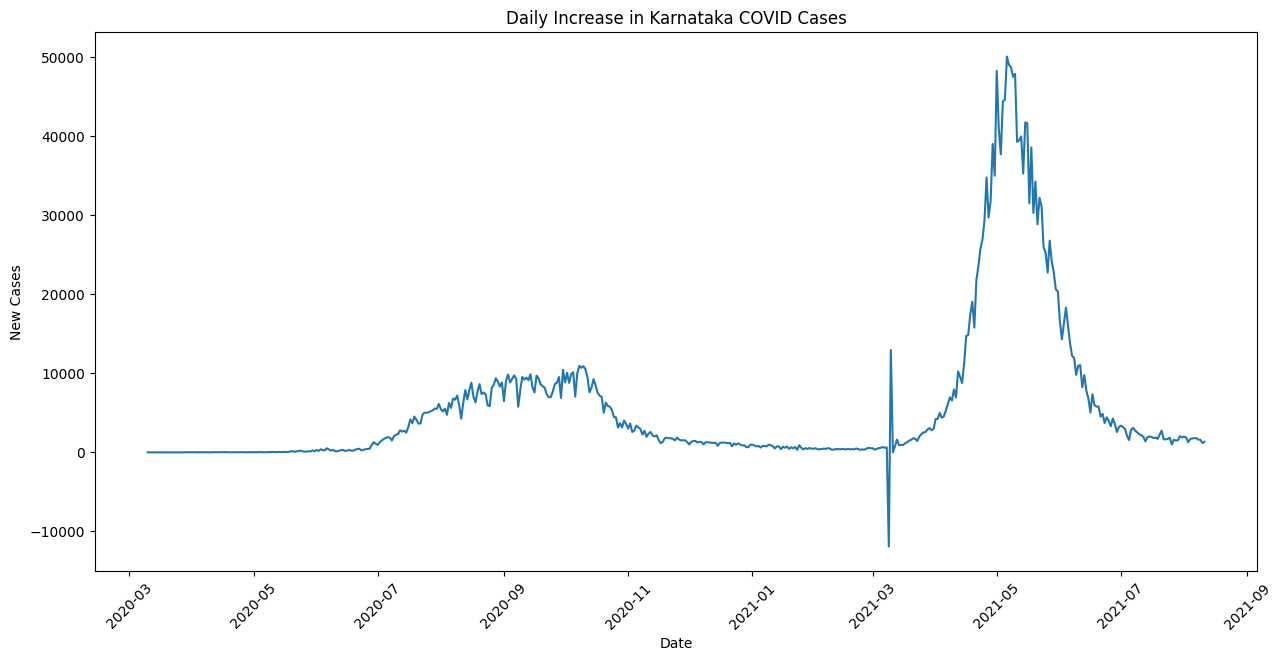

In [21]:
plt.figure(figsize=(15,7))

plt.plot(
    karnataka_data['Date'],
    karnataka_data['Daily_Increase']
)

plt.title("Daily Increase in Karnataka COVID Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")

plt.xticks(rotation=45)

plt.show()

In [37]:
karnataka_data[['Confirmed','Cured','Deaths']].T\
.style.background_gradient(cmap='Reds')

,74,89,108,119,132,145,151,165,180,195,213,233,254,277,300,323,347,376,403,430,457,484,512,542,571,601,632,662,692,722,753,784,815,846,877,908,940,973,1006,1039,1072,1105,1138,1171,1204,1236,1268,1300,1332,1364,1396,1428,1460,1492,1524,1556,1588,1620,1653,1686,1719,1752,1785,1818,1851,1884,1917,1950,1983,2016,2049,2082,2115,2149,2183,2217,2251,2286,2321,2357,2393,2429,2465,2501,2537,2573,2609,2645,2681,2717,2753,2789,2825,2861,2898,2934,2970,3006,3042,3078,3114,3150,3186,3222,3258,3294,3330,3366,3402,3438,3474,3510,3546,3582,3618,3654,3690,3726,3762,3798,3834,3870,3906,3942,3978,4014,4050,4086,4122,4158,4194,4230,4266,4301,4336,4371,4406,4441,4476,4511,4546,4581,4616,4651,4686,4721,4756,4791,4826,4861,4896,4931,4966,5001,5036,5071,5106,5141,5176,5211,5246,5281,5316,5351,5386,5421,5456,5491,5526,5561,5596,5631,5666,5701,5736,5771,5806,5841,5876,5911,5946,5981,6016,6051,6086,6121,6156,6191,6226,6261,6296,6331,6366,6401,6436,6471,6506,6541,6576,6611,6646,6681,6716,6751,6786,6821,6856,6891,6926,6961,6996,7031,7066,7101,7136,7171,7206,7241,7276,7311,7346,7381,7416,7451,7486,7521,7556,7591,7626,7661,7696,7731,7766,7801,7836,7871,7906,7941,7976,8011,8046,8081,8116,8151,8186,8221,8256,8291,8326,8361,8396,8431,8466,8501,8536,8571,8606,8641,8676,8711,8746,8781,8816,8851,8886,8921,8956,8991,9026,9061,9096,9131,9166,9201,9236,9271,9306,9341,9377,9413,9449,9485,9521,9557,9593,9629,9665,9701,9737,9773,9809,9845,9881,9917,9953,9989,10025,10061,10097,10133,10169,10205,10241,10277,10313,10349,10385,10421,10457,10493,10529,10565,10601,10637,10673,10709,10745,10781,10817,10853,10889,10925,10961,10997,11033,11069,11105,11141,11177,11213,11249,11285,11321,11357,11393,11429,11465,11501,11537,11573,11609,11645,11681,11717,11753,11789,11825,11861,11897,11933,11969,12005,12041,12077,12113,12149,12185,12221,12257,12293,12329,12365,12401,12437,12473,12509,12545,12581,12617,12653,12689,12725,12761,12797,12833,12869,12905,12941,12977,13013,13049,13085,13121,13157,13193,13229,13265,13301,13337,13373,13409,13445,13481,13517,13553,13589,13625,13661,13697,13733,13769,13805,13841,13877,13913,13949,13985,14021,14057,14093,14129,14165,14201,14237,14273,14309,14345,14381,14417,14453,14489,14525,14561,14597,14633,14669,14705,14741,14777,14813,14849,14885,14921,14957,14993,15029,15065,15101,15137,15173,15209,15245,15281,15317,15353,15389,15425,15461,15497,15533,15569,15605,15641,15677,15713,15749,15785,15821,15857,15893,15929,15965,16001,16037,16073,16109,16145,16181,16217,16253,16289,16325,16361,16397,16433,16469,16505,16541,16577,16613,16649,16685,16721,16757,16793,16829,16865,16901,16937,16973,17009,17045,17081,17117,17153,17189,17225,17261,17333,17369,17405,17441,17477,17513,17549,17585,17621,17657,17693,17729,17765,17801,17837,17873,17909,17945,17981,18017,18053,18089
Confirmed,1,4,4,4,6,6,6,6,11,11,14,15,15,26,33,37,41,55,55,55,76,83,83,101,110,124,128,144,151,175,175,181,197,214,226,247,258,277,315,353,371,384,395,415,425,443,463,489,501,511,520,532,557,576,589,606,642,659,671,693,705,753,794,848,862,925,959,987,1056,1092,1147,1246,1397,1462,1605,1743,1959,2089,2182,2283,2418,2533,2781,2922,3221,3408,3796,4063,4320,4835,5213,5452,5760,5921,6041,6245,6516,6824,7000,7213,7530,7734,7944,8281,8697,9150,9399,9721,10118,10560,11005,11923,13190,14295,15242,16514,18016,19710,21549,23474,25317,26815,28877,31105,33418,36216,38843,41581,44077,47253,51422,55115,59652,63772,67420,71069,75833,80863,85870,90942,96141,101465,107001,112504,118632,124115,129287,134819,139571,145830,151449,158254,164924,172102,178087,182354,188611,196494,203200,211108,219926,226966,233283,240948,249590,256975,264546,271876,277814,283665,291826,300406,309792,318752,327076,335928,342423,351481,361341,370206,379486,389232,398551,404324,412190,421730,430947,440411,449551,459445,467689,475265,484990,494356,502982,511346,519537,526876,533850,540847,548557,557212,566023,575566,582458,592911,601767,611837,620630,630516,640661,647712,657705,668652,679356,690269,700786,710309,717915,726106,735371,743848

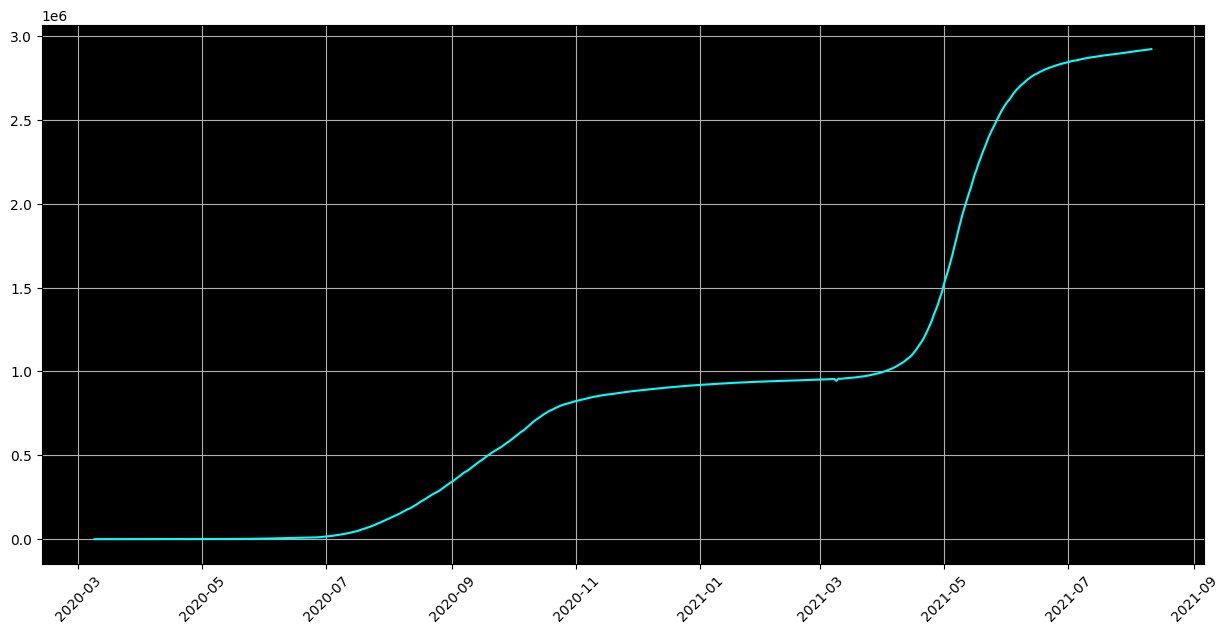

In [23]:
plt.figure(figsize=(15,7))

ax = plt.axes()

ax.set_facecolor("black")

ax.plot(
    karnataka_data['Date'],
    karnataka_data['Confirmed'],
    color='cyan'
)

ax.grid()

plt.xticks(rotation=45)

plt.show()

In [24]:
latest = covid_data.groupby(
    'State/UnionTerritory'
)['Confirmed'].max()

print(latest.sort_values(ascending=False).head(10))

State/UnionTerritory
Maharashtra       6363442
Maharashtra***    6229596
Kerala            3586693
Karnataka         2921049
Karanataka        2885238
Tamil Nadu        2579130
Andhra Pradesh    1985182
Uttar Pradesh     1708812
West Bengal       1534999
Delhi             1436852
Name: Confirmed, dtype: int64


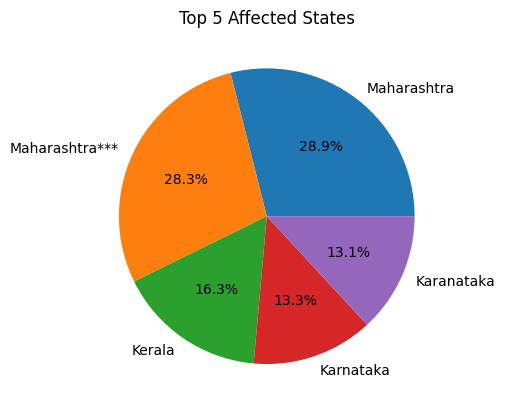

In [25]:
top_states = latest.sort_values(
    ascending=False
).head(5)

plt.pie(
    top_states,
    labels=top_states.index,
    autopct='%1.1f%%'
)

plt.title("Top 5 Affected States")

plt.show()

<Axes: >

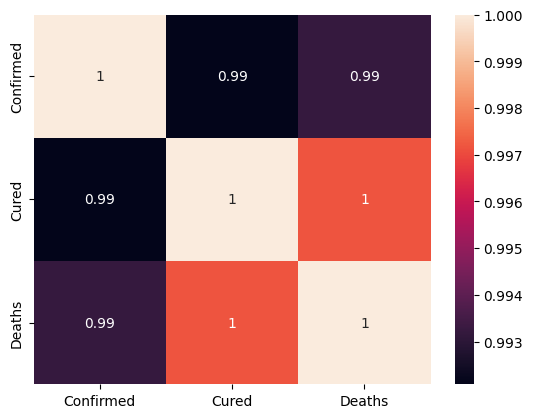

In [26]:
sns.heatmap(
    karnataka_data[['Confirmed','Cured','Deaths']].corr(),
    annot=True
)

<Axes: >

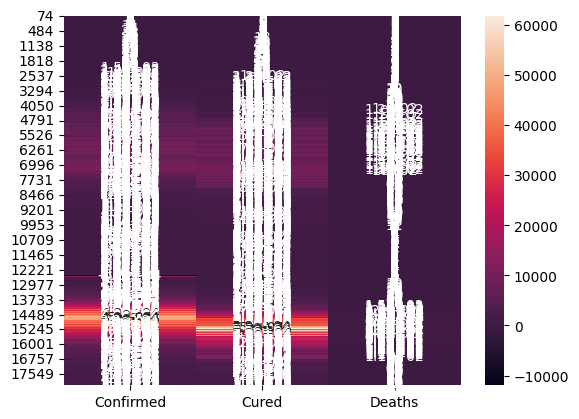

In [27]:
sns.heatmap(
    karnataka_data[['Confirmed','Cured','Deaths']].diff(),
    annot=True
)

In [28]:
state_compare = covid_data.pivot_table(
    index='Date',
    columns='State/UnionTerritory',
    values='Confirmed'
)

In [38]:
state_compare[['Karnataka',
               'Kerala',
               'Tamil Nadu',
               'Andhra Pradesh']]\
.style.bar(color='green')

State/UnionTerritory,Karnataka,Kerala,Tamil Nadu,Andhra Pradesh
Date,,,,
2020-01-30 00:00:00,nan,1.000000,nan,nan
2020-01-31 00:00:00,nan,1.000000,nan,nan
2020-02-01 00:00:00,nan,2.000000,nan,nan
2020-02-02 00:00:00,nan,3.000000,nan,nan
2020-02-03 00:00:00,nan,3.000000,nan,nan
2020-02-04 00:00:00,nan,3.000000,nan,nan
2020-02-05 00:00:00,nan,3.000000,nan,nan
2020-02-06 00:00:00,nan,3.000000,nan,nan
2020-02-07 00:00:00,nan,3.000000,nan,nan


In [39]:
state_compare[['Karnataka',
               'Kerala',
               'Tamil Nadu',
               'Andhra Pradesh']]\
.style.background_gradient(cmap='Reds')

State/UnionTerritory,Karnataka,Kerala,Tamil Nadu,Andhra Pradesh
Date,,,,
2020-01-30 00:00:00,nan,1.000000,nan,nan
2020-01-31 00:00:00,nan,1.000000,nan,nan
2020-02-01 00:00:00,nan,2.000000,nan,nan
2020-02-02 00:00:00,nan,3.000000,nan,nan
2020-02-03 00:00:00,nan,3.000000,nan,nan
2020-02-04 00:00:00,nan,3.000000,nan,nan
2020-02-05 00:00:00,nan,3.000000,nan,nan
2020-02-06 00:00:00,nan,3.000000,nan,nan
2020-02-07 00:00:00,nan,3.000000,nan,nan


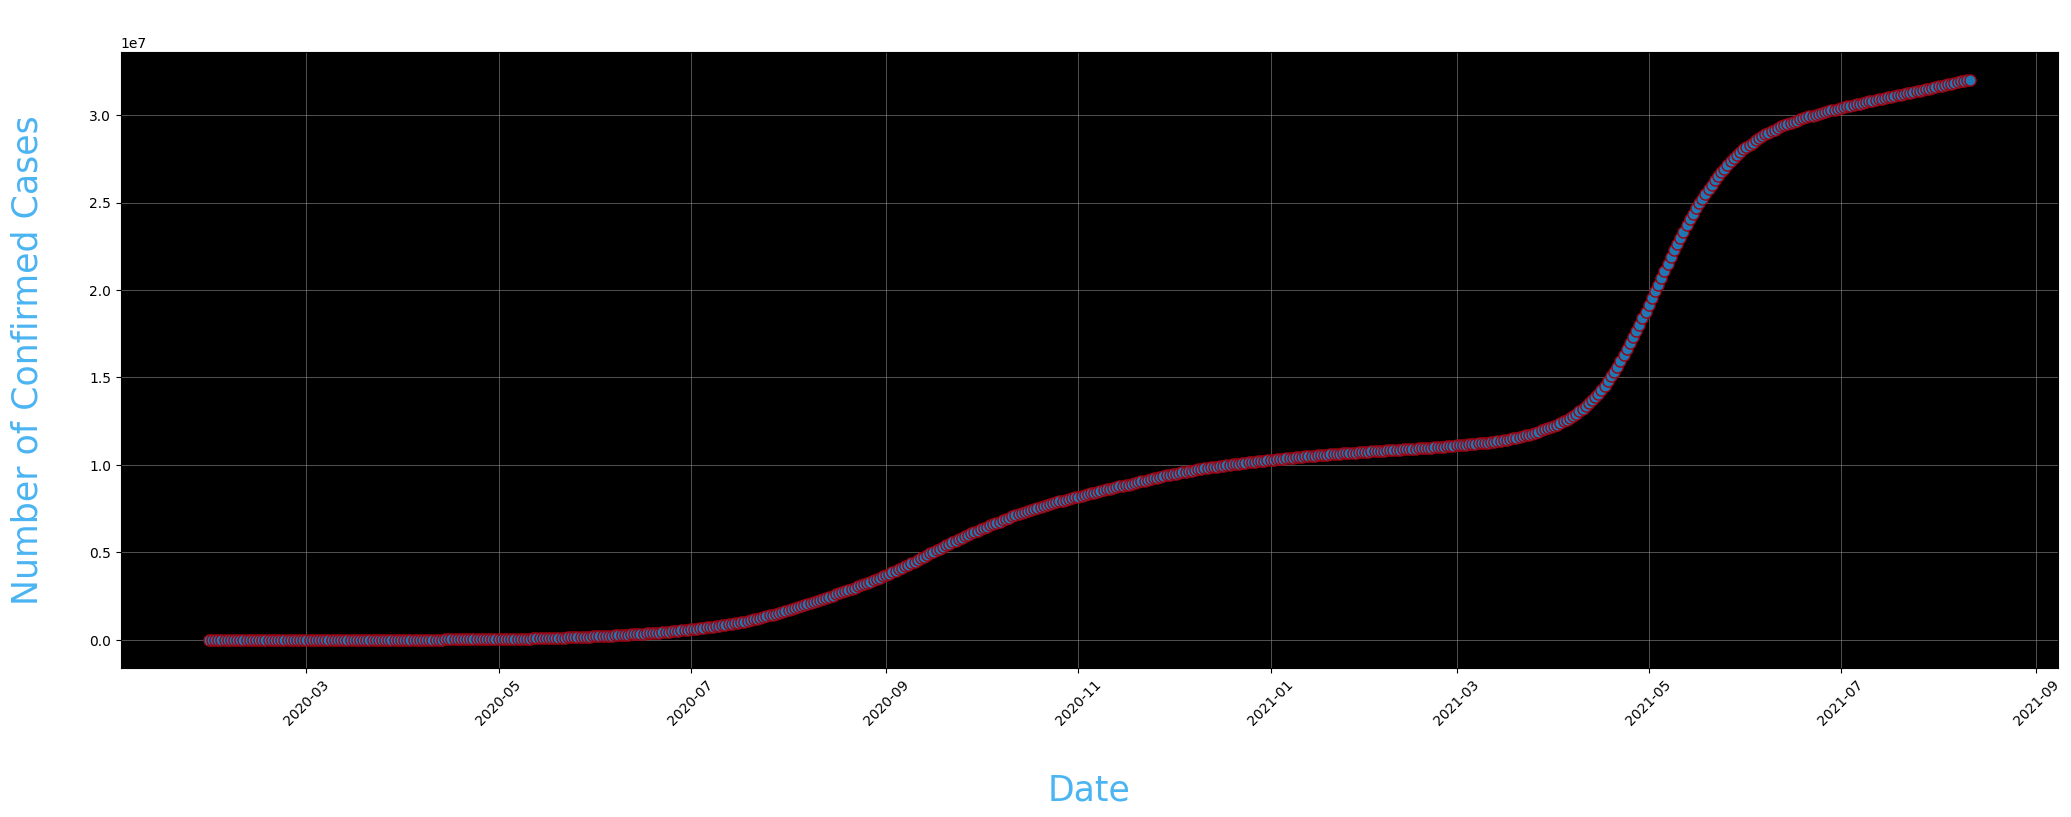

In [31]:
# data = pd.read_csv('case_time_series.csv')
india_daily = covid_data.groupby('Date')[
    ['Confirmed','Cured','Deaths']
].sum()

Y = india_daily['Confirmed'].values
R = india_daily['Cured'].values
D = india_daily['Deaths'].values
X = india_daily.index

plt.figure(figsize=(25,8))

ax = plt.axes()

ax.grid(linewidth=0.4, color='#8f8f8f')

ax.set_facecolor("black")

ax.set_xlabel(
    '\nDate',
    size=25,
    color='#4bb4f2'
)

ax.set_ylabel(
    'Number of Confirmed Cases\n',
    size=25,
    color='#4bb4f2'
)

ax.plot(
    X,
    Y,
    color='#1F77B4',
    marker='o',
    linewidth=4,
    markersize=8,
    markeredgecolor='#9b0310'
)

plt.xticks(rotation=45)

plt.title(
    "COVID-19 India Confirmed Cases",
    size=30,
    color='white'
)

plt.show()

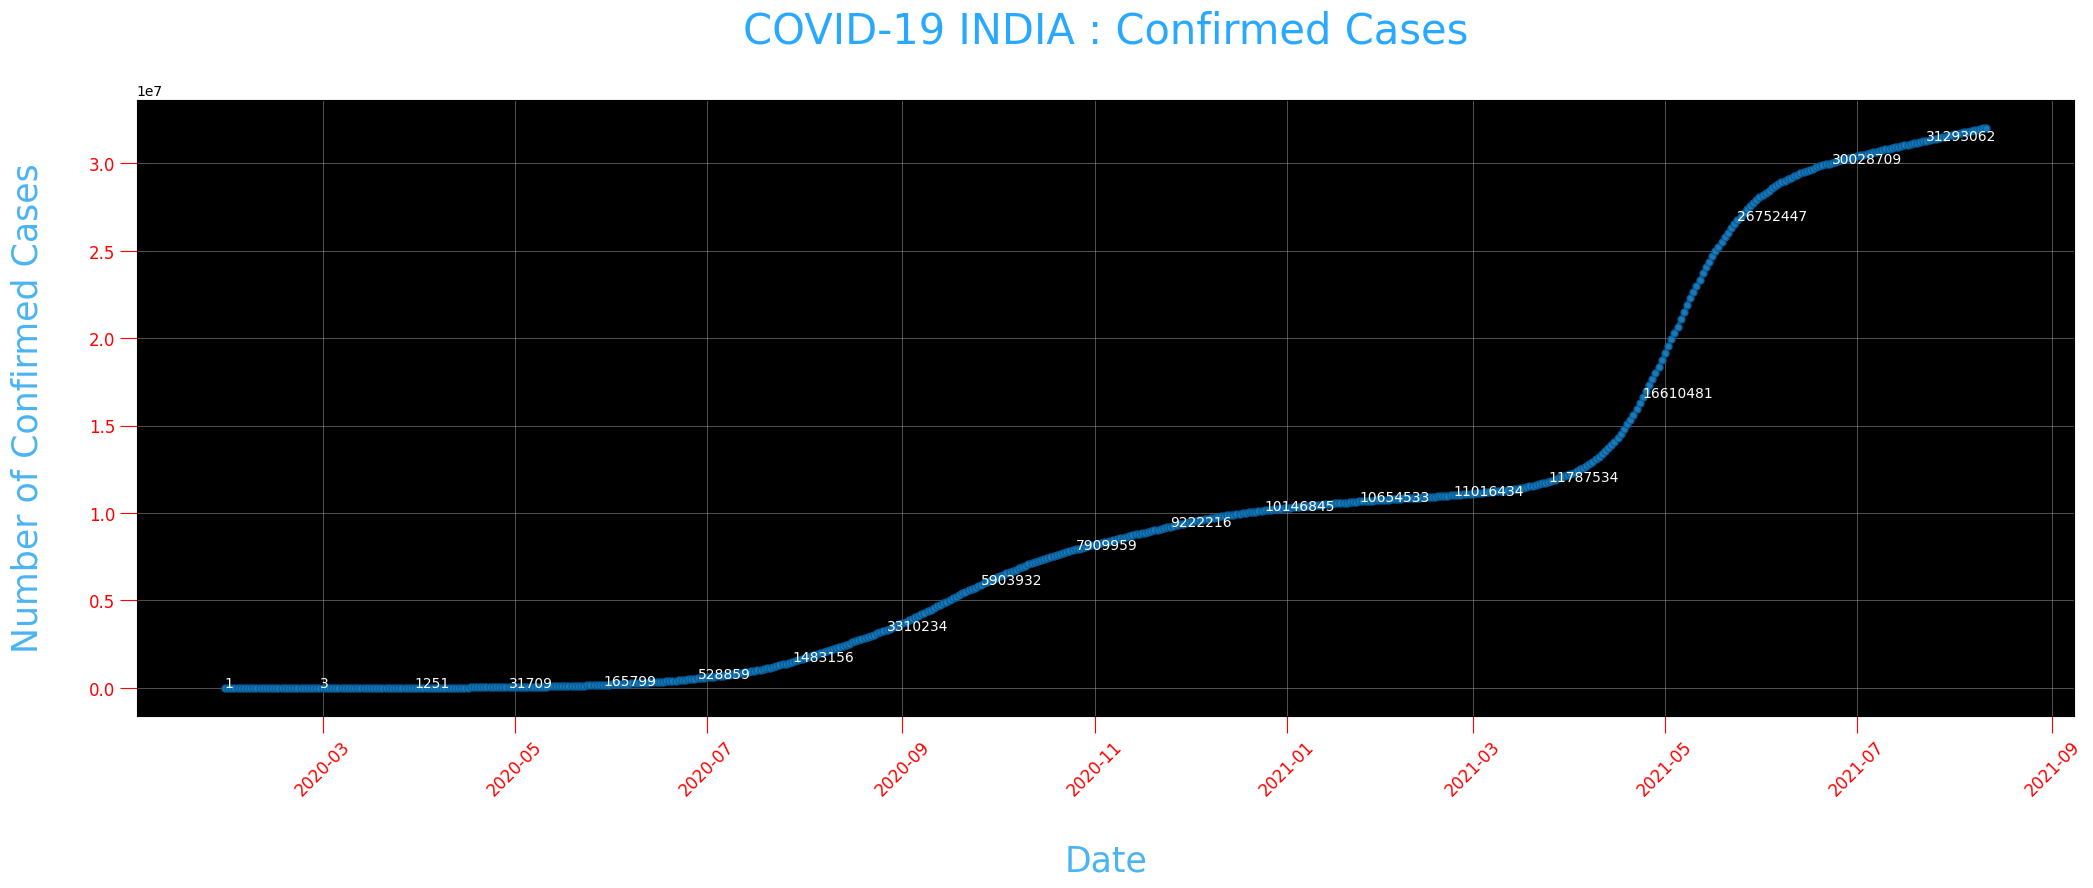

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

india_daily = covid_data.groupby('Date')[
    ['Confirmed','Cured','Deaths']
].sum()

Y = india_daily['Confirmed'].values
X = india_daily.index

plt.figure(figsize=(25,8))

ax = plt.axes()

ax.grid(linewidth=0.4, color='#8f8f8f')

ax.set_facecolor("black")

ax.set_xlabel(
    '\nDate',
    size=25,
    color='#4bb4f2'
)

ax.set_ylabel(
    'Number of Confirmed Cases\n',
    size=25,
    color='#4bb4f2'
)

plt.xticks(rotation=45,size=12,color='red')

plt.yticks(size=12,color='red')

plt.tick_params(size=12,color='red')

# Optional:
# only annotate every 30th point
for i,j in zip(X[::30],Y[::30]):
    ax.annotate(
        str(j),
        xy=(i,j+10000),
        color='white',
        size=10
    )

plt.title(
    "COVID-19 INDIA : Confirmed Cases\n",
    size=30,
    color='#28a9ff'
)

ax.plot(
    X,
    Y,
    color='#1F77B4',
    marker='o',
    linewidth=2,
    markersize=5,
    markeredgecolor='#035E9B'
)



plt.show()

In [35]:
ax.annotate(
    'Lockdown Begins',
    xy=('2020-03-25', 600),
    xytext=('2020-05-01', 200000),
    arrowprops=dict(color='white'),
    color='white'
)

Text(2020-05-01, 200000, 'Lockdown Begins')

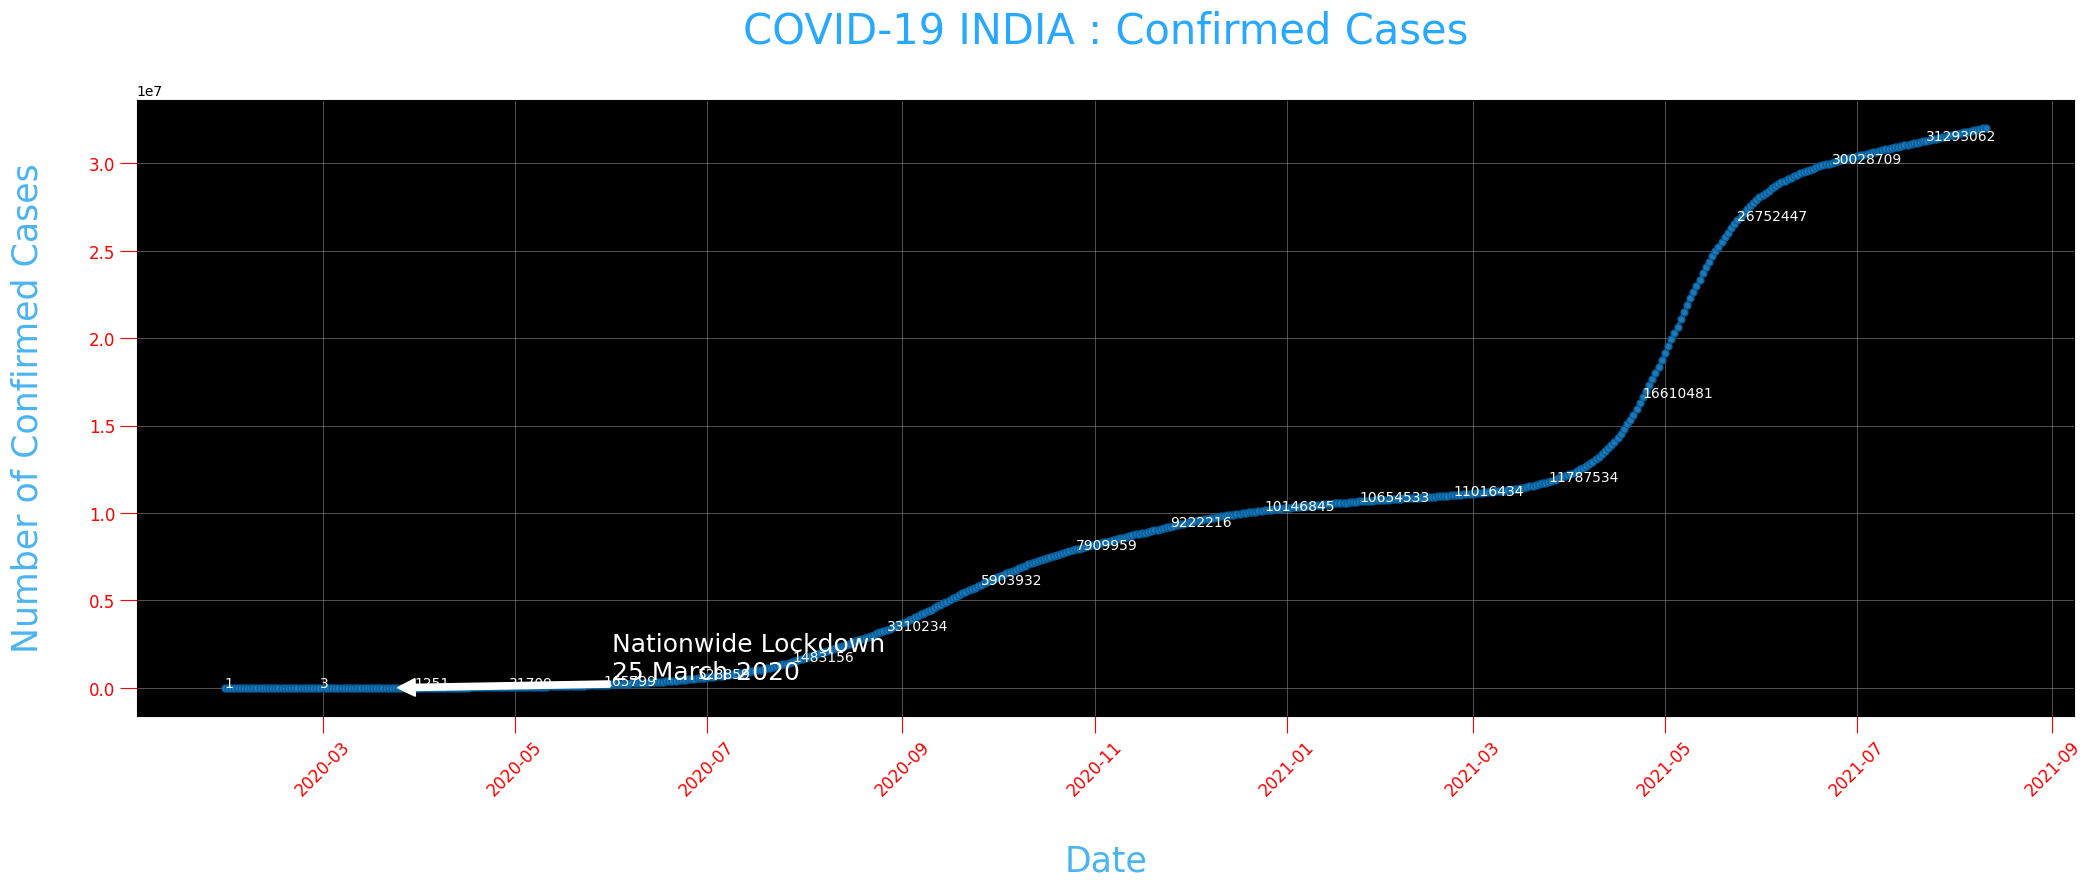

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# GROUP INDIA-WISE DATA DATE-WISE
india_daily = covid_data.groupby('Date')[
    ['Confirmed', 'Cured', 'Deaths']
].sum()

# EXTRACT VALUES
Y = india_daily['Confirmed'].values
R = india_daily['Cured'].values
D = india_daily['Deaths'].values
X = india_daily.index

# CREATE FIGURE
plt.figure(figsize=(25,8))

# CREATE AXES
ax = plt.axes()

# GRID
ax.grid(linewidth=0.4, color='#8f8f8f')

# BACKGROUND COLOR
ax.set_facecolor("black")

# X LABEL
ax.set_xlabel(
    '\nDate',
    size=25,
    color='#4bb4f2'
)

# Y LABEL
ax.set_ylabel(
    'Number of Confirmed Cases\n',
    size=25,
    color='#4bb4f2'
)

# X TICKS
plt.xticks(
    rotation=45,
    size=12,
    color='red'
)

# Y TICKS
plt.yticks(
    size=12,
    color='red'
)

# TICK PARAMETERS
plt.tick_params(
    size=12,
    color='red'
)

# ANNOTATE VALUES
# Using every 30th point to avoid clutter
for i, j in zip(X[::30], Y[::30]):

    ax.annotate(
        str(j),
        xy=(i, j + 10000),
        color='white',
        size=10
    )

# LOCKDOWN ANNOTATION
ax.annotate(
    'Nationwide Lockdown\n25 March 2020',

    xy=(
        pd.to_datetime('2020-03-25'),
        india_daily.loc[
            '2020-03-25',
            'Confirmed'
        ]
    ),

    xytext=(
        pd.to_datetime('2020-06-01'),
        500000
    ),

    color='white',
    size=18,

    arrowprops=dict(
        color='white',
        linewidth=1.5
    )
)

# TITLE
plt.title(
    "COVID-19 INDIA : Confirmed Cases\n",
    size=30,
    color='#28a9ff'
)

# MAIN PLOT
ax.plot(
    X,
    Y,

    color='#1F77B4',

    marker='o',

    linewidth=2,

    markersize=5,

    markeredgecolor='#035E9B'
)

# SHOW GRAPH
plt.show()